In [ ]:
!pip install langchain-text-splitters
!pip install langchain-openai

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rmaomina/llm_service_modu6/blob/main/Colab%20Notebooks/w2_token_embedding_vector_rag/llm_260318_embedding_cache.ipynb)

In [12]:
!pip install langchain_classic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.5/503.5 kB 32.8 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.18
    Uninstalling langchain-core-1.2.18:
      Successfully uninstalled langchain-core-1.2.18


In [8]:
import os
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

from google.colab import userdata
api_key = userdata.get('OPENAI_API_KEY')

In [34]:
llm = ChatOpenAI(model='gpt-4o-mini', api_key=api_key)
embeddings_model = OpenAIEmbeddings(model='text-embedding-3-small', api_key=api_key)

In [20]:
# Embedding Cache 이어서...
text_emb = embeddings_model.embed_query('Hello')

In [30]:
from langchain_classic.embeddings import CacheBackedEmbeddings
from langchain_core.stores import InMemoryByteStore

In [21]:
store = InMemoryByteStore()
cached_embeddings = CacheBackedEmbeddings.from_bytes_store(
  embeddings_model, store, namespace="embedding-cache"
)

/usr/local/lib/python3.12/dist-packages/langchain_classic/embeddings/cache.py:58: UserWarning: Using default key encoder: SHA-1 is *not* collision-resistant. While acceptable for most cache scenarios, a motivated attacker can craft two different payloads that map to the same cache key. If that risk matters in your environment, supply a stronger encoder (e.g. SHA-256 or BLAKE2) via the `key_encoder` argument. If you change the key encoder, consider also creating a new cache, to avoid (the potential for) collisions with existing keys.
  _warn_about_sha1_encoder()


In [22]:
texts = ['인공지능이 계속 발전하고 있습니다.', 'Langchain으로 RAG를 구현합시다.']
vecs1 = cached_embeddings.embed_documents(texts)
len(vecs1[0]), len(vecs1[1])

(1536, 1536)

In [23]:
start = time.time()
texts = ["오늘 점심에는 라면을 먹었습니다", "내일 저녁에는 햄버거를 먹을겁니다"]
vecs1 = cached_embeddings.embed_documents(texts)
t1 = time.time() - start
print(f"1차 call, {t1}초")

start = time.time()
vecs2 = cached_embeddings.embed_documents(texts)
t2 = time.time() - start
print(f"2차 call, {t2}초")

1차 call, 1.0002589225769043초
2차 call, 0.0017392635345458984초


In [24]:
# 중간에 배치가 끝날때마다 실행시간, 처리토큰 출력하는 함수
# 모든 문서가 완료되었을 때 소요시간과 전체 처리 토큰을 출력
import time
import tiktoken

def process_documents(docs, embedding_model, batch_size=5):
    all_vectors = []
    total_tokens = 0
    total_start = time.time()

    enc = tiktoken.encoding_for_model("text-embedding-3-small")

    for i in range(0, len(docs), batch_size):
        batch = docs[i:i + batch_size]
        batch_start = time.time()

        vectors = embedding_model.embed_documents(batch)
        all_vectors.extend(vectors)

        batch_tokens = sum(len(enc.encode(doc)) for doc in batch)
        total_tokens += batch_tokens

        batch_time = time.time() - batch_start
        print(f"배치 {i // batch_size + 1} 완료 | 소요시간: {batch_time:.4f}초 | 처리 토큰: {batch_tokens}")

    total_time = time.time() - total_start
    print(f"\n전체 완료 | 총 소요시간: {total_time:.4f}초 | 전체 처리 토큰: {total_tokens}")

    return all_vectors

In [27]:
documents = [
    "AI는 대량의 데이터를 학습하여 패턴을 인식한다.",
    "머신러닝은 AI의 한 분야로, 경험을 통해 성능을 향상시킨다.",
    "딥러닝은 신경망을 여러 층으로 쌓아 복잡한 문제를 해결한다.",
    "자연어처리(NLP)는 컴퓨터가 인간의 언어를 이해하도록 돕는다.",
    "AI 교육은 논리적 사고력과 문제 해결 능력을 함께 키워준다.",
    "챗봇은 자연어처리 기술을 활용한 대화형 AI 시스템이다.",
    "강화학습은 보상과 패널티를 통해 AI가 최적의 행동을 학습한다.",
    "컴퓨터 비전은 이미지와 영상을 분석하는 AI 기술이다.",
    "AI 윤리는 인공지능 기술의 공정하고 책임 있는 사용을 다룬다.",
    "프롬프트 엔지니어링은 AI 모델에서 원하는 결과를 얻는 기술이다.",
]

vectors = process_documents(documents, embeddings_model, batch_size=2)

배치 1 완료 | 소요시간: 0.9437초 | 처리 토큰: 57
배치 2 완료 | 소요시간: 0.1428초 | 처리 토큰: 69
배치 3 완료 | 소요시간: 0.6760초 | 처리 토큰: 73
배치 4 완료 | 소요시간: 0.1752초 | 처리 토큰: 65
배치 5 완료 | 소요시간: 0.2274초 | 처리 토큰: 66

전체 완료 | 총 소요시간: 2.1655초 | 전체 처리 토큰: 330


In [29]:
vectors = process_documents(documents, embeddings_model, batch_size=2)

배치 1 완료 | 소요시간: 0.3678초 | 처리 토큰: 57
배치 2 완료 | 소요시간: 0.7551초 | 처리 토큰: 69
배치 3 완료 | 소요시간: 0.2357초 | 처리 토큰: 73
배치 4 완료 | 소요시간: 0.1801초 | 처리 토큰: 65
배치 5 완료 | 소요시간: 0.1464초 | 처리 토큰: 66

전체 완료 | 총 소요시간: 1.6857초 | 전체 처리 토큰: 330


In [30]:
vectors = process_documents(documents, embeddings_model, batch_size=5)

배치 1 완료 | 소요시간: 0.9808초 | 처리 토큰: 163
배치 2 완료 | 소요시간: 0.7895초 | 처리 토큰: 167

전체 완료 | 총 소요시간: 1.7706초 | 전체 처리 토큰: 330


In [31]:
vectors = process_documents(documents, embeddings_model, batch_size=5)

배치 1 완료 | 소요시간: 0.2689초 | 처리 토큰: 163
배치 2 완료 | 소요시간: 0.1882초 | 처리 토큰: 167

전체 완료 | 총 소요시간: 0.4572초 | 전체 처리 토큰: 330


In [32]:
# 선생님 답변
import tiktoken
def count_token(text, model = 'gpt-4o-mini'):
  enc = tiktoken.encoding_for_model(model)
  return len(enc.encode(text))

In [34]:
def process_documents2(docs, embedding_model, batch_size = 5):
  all_vectors = []
  total_tokens = 0
  start = time.time()

  for i in range(0, len(docs), batch_size):
    batch = docs[i:i+batch_size] # 0~4, 5~9 ...
    batch_tokens = sum(count_token(doc) for doc in batch)
    total_tokens += batch_tokens

    vectors = embedding_model.embed_documents(batch)
    all_vectors.extend(vectors) # append -> [1,2,3].append(6)

    progress = min(i + batch_size, len(docs))
    print(f' [{progress} / {len(docs)}] batch {i // batch_size + 1} process ({batch_tokens} tokens)')

  elapsed = time.time() - start
  print(f'completed, {len(docs)} documents, {total_tokens}')
  print(f' {elapsed} seconds ')

  return all_vectors

In [39]:
documents2 = [f'doc {i} : 이것은 테스트 문서입니다. 인공지능 관련... ' for i in range(100)]
vectors2 = process_documents2(documents2, embeddings_model, batch_size=5)

 [5 / 100] batch 1 process (85 tokens)
 [10 / 100] batch 2 process (85 tokens)
 [15 / 100] batch 3 process (85 tokens)
 [20 / 100] batch 4 process (85 tokens)
 [25 / 100] batch 5 process (85 tokens)
 [30 / 100] batch 6 process (85 tokens)
 [35 / 100] batch 7 process (85 tokens)
 [40 / 100] batch 8 process (85 tokens)
 [45 / 100] batch 9 process (85 tokens)
 [50 / 100] batch 10 process (85 tokens)
 [55 / 100] batch 11 process (85 tokens)
 [60 / 100] batch 12 process (85 tokens)
 [65 / 100] batch 13 process (85 tokens)
 [70 / 100] batch 14 process (85 tokens)
 [75 / 100] batch 15 process (85 tokens)
 [80 / 100] batch 16 process (85 tokens)
 [85 / 100] batch 17 process (85 tokens)
 [90 / 100] batch 18 process (85 tokens)
 [95 / 100] batch 19 process (85 tokens)
 [100 / 100] batch 20 process (85 tokens)
completed, 100 documents, 1700
 4.439143896102905 seconds 


In [35]:
# Cosine Similarity 코사인 유사도
# 자연어 보다는 벡터로 임베딩해서 연산을 통한 결과 도출
# 대부분 벡터 스페이스에서 벡터로 존재하며 벡터들의 관계가 어떻게 연관되어 있는지
# Cosine 0도 일 때, 1이라는 가장 큰 값을 가지고, 180도일 때 가장 작은 -1 이라는 값을 가짐.
from sklearn.metrics.pairwise import cosine_similarity

In [47]:
# 자연어를 임베딩(벡터화)
pairs = [
    ('오늘 날씨가 참 좋다.', '오늘은 날씨가 화창한 날이다.'),
    ('오늘 날씨가 참 좋다.', '오늘은 날씨가 안좋다.'),
    ('파이썬 프로그래밍', 'python programming'),
    ('인공지능 기술의 발전', '엄마가 끓여주는 김치찌개'),
    ('서울은 한국의 수도이다.', 'Seoul is the capital city in Korea')
]
pairs2 = [
    ('이 치킨 진짜 맛없다', '이 치킨 진짜 맛있다'),
    ('배고파 죽겠다', '밥 언제 먹어'),
    ('나 너 좋아해', 'I like you'),
    ('완전 핵노잼이다', '정말 재미없다'),
    ('오늘 주식이 폭락했다', '강아지가 공을 물고 뛴다'),
    ('시험 붙었다 너무 기뻐', '시험 떨어졌다 너무 슬퍼'),
    ('그 사람은 여우 같다', '그 사람은 교활하다'),
    ('그 영화 레전드다 ㄹㅇ', '그 영화 정말 훌륭했습니다'),
    ('금리가 올랐다', '대출 이자가 부담된다'),
    ('인간은 본래 선하다', '인간은 본래 악하다'),
]

def pair_similar_decoder(pairs):
  for text_a, text_b in pairs:
    embs = embeddings_model.embed_documents([text_a, text_b])
    simi = cosine_similarity([embs[0]], [embs[1]])[0][0]

    print(f'similarity: {simi}, {text_a}, {text_b}')

In [48]:
pair_similar_decoder(pairs)
print(' ===== ')
pair_similar_decoder(pairs2)

similarity: 0.6996302561453703, 오늘 날씨가 참 좋다., 오늘은 날씨가 화창한 날이다.
similarity: 0.8396518549117835, 오늘 날씨가 참 좋다., 오늘은 날씨가 안좋다.
similarity: 0.3880830000982095, 파이썬 프로그래밍, python programming
similarity: 0.08277189856356476, 인공지능 기술의 발전, 엄마가 끓여주는 김치찌개
similarity: 0.45916514745161385, 서울은 한국의 수도이다., Seoul is the capital city in Korea
 ===== 
similarity: 0.954634054870555, 이 치킨 진짜 맛없다, 이 치킨 진짜 맛있다
similarity: 0.18310859141489155, 배고파 죽겠다, 밥 언제 먹어
similarity: 0.43859622967244366, 나 너 좋아해, I like you
similarity: 0.25171002935650577, 완전 핵노잼이다, 정말 재미없다
similarity: 0.08905517467883112, 오늘 주식이 폭락했다, 강아지가 공을 물고 뛴다
similarity: 0.7496413819732015, 시험 붙었다 너무 기뻐, 시험 떨어졌다 너무 슬퍼
similarity: 0.46559681289585136, 그 사람은 여우 같다, 그 사람은 교활하다
similarity: 0.44365870317286943, 그 영화 레전드다 ㄹㅇ, 그 영화 정말 훌륭했습니다
similarity: 0.1501919742651771, 금리가 올랐다, 대출 이자가 부담된다
similarity: 0.7588801110271672, 인간은 본래 선하다, 인간은 본래 악하다


In [53]:
# vectorize 후, query와의 cosine-similarity를 계산해서
# return 가장 유사한 문장을 리턴하세요.
corpus = [
    "LangChain은 LLM 앱 개발 프레임워크입니다",
    "RAG는 검색 증강 생성 기술입니다",
    "벡터 데이터베이스는 임베딩을 저장합니다",
    "파인튜닝은 모델을 특정 데이터에 맞게 조정합니다",
    "프롬프트 엔지니어링은 AI에게 좋은 지시를 작성하는 기술입니다",
    "LangChain으로 챗봇 만들기",
    "React vs Vue 성능 비교",
    "GPT API 활용 가이드",
]
query = 'AI 챗봇 개발하고 싶어요'
def find_most_similar(query, corpus):
    query_emb = embeddings_model.embed_documents([query])[0]

    best_score = -1
    best_sentence = None

    for c in corpus:
        c_emb = embeddings_model.embed_documents([c])[0]
        simi = cosine_similarity([query_emb], [c_emb])[0][0]

        print(f'similarity: {simi:.4f} | {c}')

        if simi > best_score:
            best_score = simi
            best_sentence = c

    print(f'\nMost Similar Sentense: {best_sentence} ({best_score:.4f})')
    return best_sentence

find_most_similar(query, corpus)

similarity: 0.3135 | LangChain은 LLM 앱 개발 프레임워크입니다
similarity: 0.2419 | RAG는 검색 증강 생성 기술입니다
similarity: 0.1852 | 벡터 데이터베이스는 임베딩을 저장합니다
similarity: 0.2059 | 파인튜닝은 모델을 특정 데이터에 맞게 조정합니다
similarity: 0.2638 | 프롬프트 엔지니어링은 AI에게 좋은 지시를 작성하는 기술입니다
similarity: 0.5934 | LangChain으로 챗봇 만들기
similarity: 0.1497 | React vs Vue 성능 비교
similarity: 0.2130 | GPT API 활용 가이드

Most Similar Sentense: LangChain으로 챗봇 만들기 (0.5934)


'LangChain으로 챗봇 만들기'

In [54]:
query2 = 'GEMINI가 좋아요? GPT가 좋아요?'
find_most_similar(query, corpus)

similarity: 0.3135 | LangChain은 LLM 앱 개발 프레임워크입니다
similarity: 0.2395 | RAG는 검색 증강 생성 기술입니다
similarity: 0.1854 | 벡터 데이터베이스는 임베딩을 저장합니다
similarity: 0.2059 | 파인튜닝은 모델을 특정 데이터에 맞게 조정합니다
similarity: 0.2638 | 프롬프트 엔지니어링은 AI에게 좋은 지시를 작성하는 기술입니다
similarity: 0.5934 | LangChain으로 챗봇 만들기
similarity: 0.1496 | React vs Vue 성능 비교
similarity: 0.2131 | GPT API 활용 가이드

Most Similar Sentense: LangChain으로 챗봇 만들기 (0.5934)


'LangChain으로 챗봇 만들기'

In [57]:
def find_most_similar2(query, corpus):
  all_texts = [query] + corpus
  all_embs = embeddings_model.embed_documents(all_texts)
  query_emb = all_embs[0]
  corpus_emb = all_embs[1:]

  sims = cosine_similarity([query_emb], corpus_emb)[0]
  ranked = sorted(enumerate(sims), key=lambda x: x[1], reverse=True)

  for rank, (idx, sim) in enumerate(ranked):
    print(f'{rank} sim : {sim}, {corpus[idx]}')

  return ranked[0]

find_most_similar2(query2, corpus)

0 sim : 0.42774473130223856, GPT API 활용 가이드
1 sim : 0.19802821976893895, 벡터 데이터베이스는 임베딩을 저장합니다
2 sim : 0.1776316860524142, LangChain은 LLM 앱 개발 프레임워크입니다
3 sim : 0.17603104500490996, 파인튜닝은 모델을 특정 데이터에 맞게 조정합니다
4 sim : 0.1685278144864385, React vs Vue 성능 비교
5 sim : 0.16810271643184754, RAG는 검색 증강 생성 기술입니다
6 sim : 0.1674027583708892, LangChain으로 챗봇 만들기
7 sim : 0.16130430821800573, 프롬프트 엔지니어링은 AI에게 좋은 지시를 작성하는 기술입니다


(7, np.float64(0.42774473130223856))

In [42]:
# Embedding 시각화 - 1536 매트릭스 -> 2,3차원의 데이터 압축
# PCA, tSNE
# Principal Components Analysis
# 데이터가 구성되는 공간을 수학적으로 분석 후
# 분산이 큰 축 기준으로 압축 (빠름, 상대적으로 흐린 군집, 항상 동일한 재현성)
from sklearn.decomposition import PCA
# t-distributed Stochastic Neighbor Embedding
# 거리 관계 유지하며 압축 (느림, 뚜렷하게 뭉침) random_state 고정 필요
from sklearn.manifold import TSNE

topic_sentences = {
    "tech": [
        "인공지능이 산업을 혁신하고 있다",
        "클라우드 컴퓨팅이 IT를 변화시킨다",
        "블록체인이 금융을 바꾸고 있다",
        "5G가 통신을 혁신한다",
    ],
    "sports": [
        "축구 경기에서 역전골이 터졌다",
        "올림픽에서 금메달을 획득했다",
        "야구 시즌이 개막했다",
        "마라톤 대회에서 신기록을 세웠다",
    ],
    "food": [
        "이 레스토랑의 파스타가 맛있었다",
        "한국 김치는 발효 식품이다",
        "새로운 카페에서 커피를 마셨다",
        "맛집 탐방이 요즘 인기다",
    ],
    "finance": [
        "주식 시장이 크게 하락했다",
        "비트코인 가격이 급등했다",
        "금리 인상이 예상된다",
        "환율이 급변하고 있다",
    ],
}

In [61]:
all_texts = []
all_labels = []

for topic, sents in topic_sentences.items():
  all_texts.extend(sents)
  all_labels.extend([topic] * len(sents))

all_texts
all_labels

['tech',
 'tech',
 'tech',
 'tech',
 'sports',
 'sports',
 'sports',
 'sports',
 'food',
 'food',
 'food',
 'food',
 'finance',
 'finance',
 'finance',
 'finance']

In [64]:
all_embs = embeddings_model.embed_documents(all_texts)
len(all_embs), len(all_embs[0])

(16, 1536)

In [67]:
import numpy as np
emb_matrix = np.array(all_embs)
emb_matrix

array([[ 5.53131104e-03,  8.70513916e-03,  2.40173340e-02, ...,
        -1.49459839e-02, -1.50394440e-03,  1.42974854e-02],
       [-1.26266479e-02,  8.85772705e-03,  3.22265625e-02, ...,
        -5.47180176e-02,  7.98797607e-03, -2.30865479e-02],
       [-1.30462646e-02,  4.10766602e-02, -1.60369873e-02, ...,
        -1.86614990e-02,  1.55868530e-02,  3.84521484e-03],
       ...,
       [-2.75268555e-02, -3.58581543e-02, -2.79998779e-02, ...,
         8.47625732e-03, -3.39150429e-05,  2.29949951e-02],
       [ 3.85742188e-02,  2.89611816e-02, -2.80303955e-02, ...,
        -9.64355469e-03,  1.01318359e-02,  8.15391541e-04],
       [-1.81732178e-02,  4.37545776e-03,  6.41632080e-03, ...,
        -1.42745972e-02, -2.41699219e-02, -1.98669434e-02]])

In [71]:
# emb_matrix를 가지고 차원을 축소
pca = PCA(n_components=2) # 초기화
coords_2d = pca.fit_transform(emb_matrix)
coords_2d # 16개의 pair, 1536차원의 데이터를 2차원의 데이터 16개로 변환

array([[ 0.35170239,  0.19006785],
       [ 0.39919439,  0.25924872],
       [-0.07874589,  0.26872724],
       [ 0.37012773,  0.24068524],
       [-0.44261732, -0.0313844 ],
       [-0.50987764,  0.09992861],
       [-0.29351294,  0.03914416],
       [-0.3953184 , -0.22857247],
       [ 0.04978012, -0.55120915],
       [ 0.24293243, -0.32010718],
       [ 0.3680971 , -0.39661434],
       [ 0.12779875, -0.43773155],
       [-0.04681523, -0.09627297],
       [ 0.08999179,  0.316875  ],
       [-0.38860399,  0.19621859],
       [ 0.15586672,  0.45099665]])

In [40]:
import matplotlib.pyplot as pit

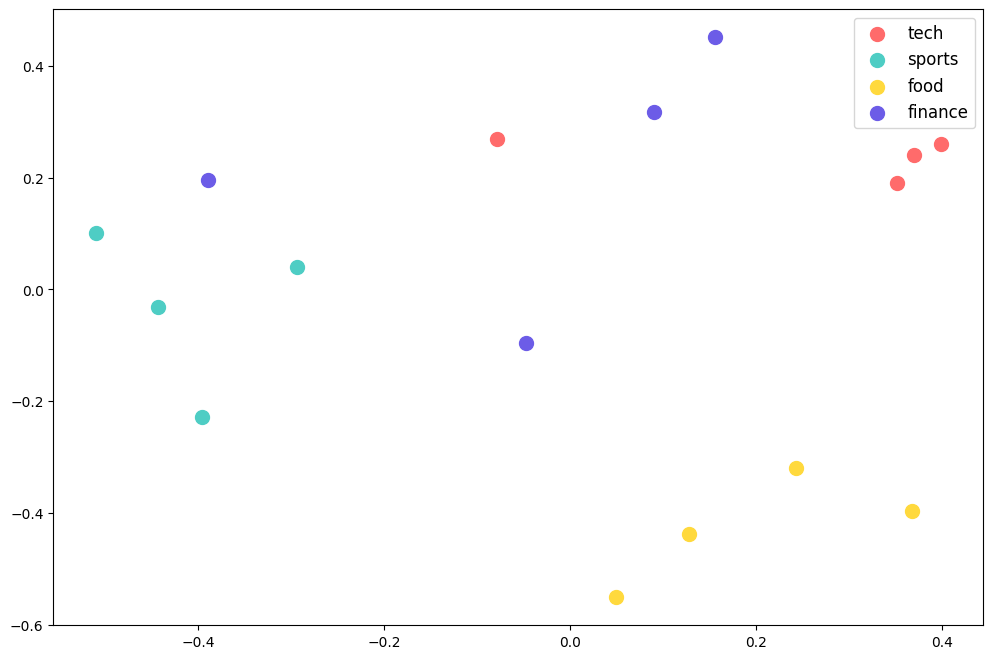

In [73]:
colors = {"tech": "#FF6B6B", "sports": "#4ECDC4", "food": "#FFD93D", "finance": "#6C5CE7"}
fig, ax = pit.subplots(figsize=(12, 8))
for topic in topic_sentences:
  mask = [I == topic for I in all_labels]
  x = coords_2d[mask, 0]
  y = coords_2d[mask, 1]
  ax.scatter(x, y, c=colors[topic], label=topic, s = 100)

ax.legend(fontsize=12)
# 모델이 바라보는 데이터의 압축된 축소판

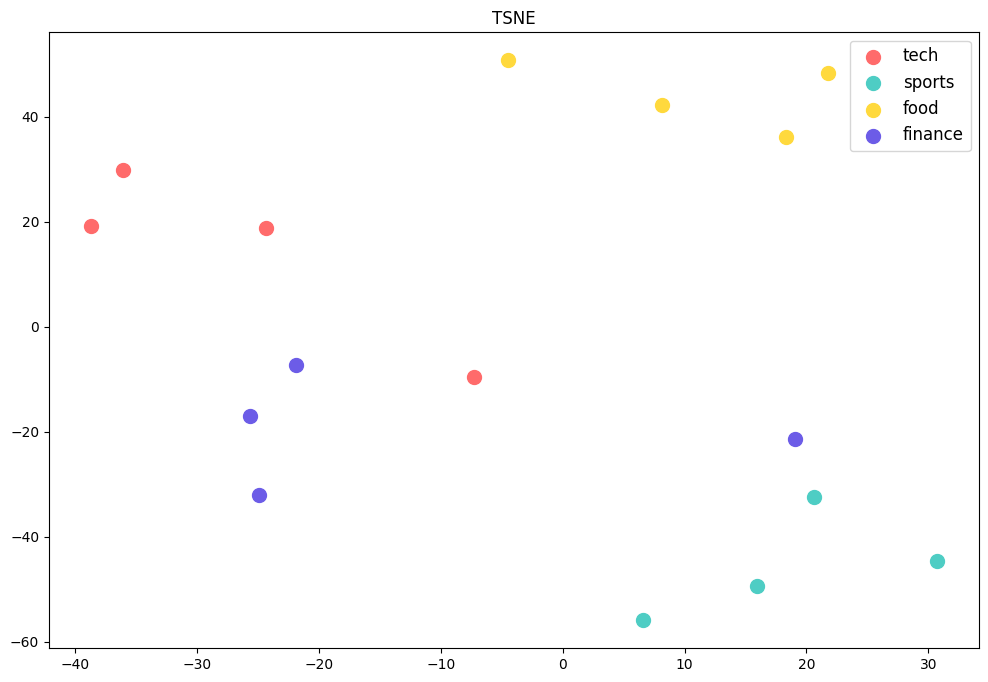

In [82]:
tsne = TSNE(n_components=2, random_state=40, perplexity=5)
coords_tsne = tsne.fit_transform(emb_matrix)

fig, ax = plt.subplots(figsize=(12, 8))
for topic in topic_sentences:
    mask = [l == topic for l in all_labels]
    x = coords_tsne[mask, 0]
    y = coords_tsne[mask, 1]
    ax.scatter(x, y, c=colors[topic], label=topic, s=100)

ax.legend(fontsize=12)
ax.set_title('TSNE')
plt.show()

In [ ]:
!pip install langchain_community
!pip install faiss-cpu

In [11]:
# FAISS (Facebook AI Similarity Search)
from langchain_community.vectorstores import FAISS
faq_docs = [
    "LangChain은 LLM 애플리케이션 개발을 위한 프레임워크입니다.",
    "RAG는 외부 문서를 검색하여 LLM 답변 정확도를 높이는 기술입니다.",
    "벡터 데이터베이스는 임베딩 벡터를 효율적으로 저장하고 검색합니다.",
    "프롬프트 엔지니어링은 AI에게 효과적인 지시를 작성하는 기술입니다.",
    "파인튜닝은 사전학습된 모델을 특정 도메인 데이터로 추가 학습시킵니다.",
    "토큰은 LLM이 텍스트를 처리하는 기본 단위입니다.",
    "임베딩은 텍스트를 수치 벡터로 변환하는 기술입니다.",
    "LCEL은 LangChain의 체인 구성을 위한 표현식 언어입니다.",
    "에이전트는 LLM이 도구를 사용해서 자율적으로 작업하는 시스템입니다.",
    "Gradio는 ML 모델을 위한 간단한 웹 인터페이스를 만드는 라이브러리입니다.",
]

In [15]:
vectorstore = FAISS.from_texts(faq_docs, embeddings_model)
queries = [
    'RAG가 뭐예요?',
    'AI 챗봇을 어떻게 만드나요?',
    '토큰 비용을 줄이고 싶어요'
]

for query in queries:
  results = vectorstore.similarity_search_with_score(query, k=3)
  for doc, score in results:
    print(f' [{score}] {doc.page_content}')
  print(" ===== ")

 [0.9826197624206543] RAG는 외부 문서를 검색하여 LLM 답변 정확도를 높이는 기술입니다.
 [1.5106987953186035] 토큰은 LLM이 텍스트를 처리하는 기본 단위입니다.
 [1.5686819553375244] Gradio는 ML 모델을 위한 간단한 웹 인터페이스를 만드는 라이브러리입니다.
 ===== 
 [1.4891736507415771] 프롬프트 엔지니어링은 AI에게 효과적인 지시를 작성하는 기술입니다.
 [1.5330579280853271] Gradio는 ML 모델을 위한 간단한 웹 인터페이스를 만드는 라이브러리입니다.
 [1.5818121433258057] LangChain은 LLM 애플리케이션 개발을 위한 프레임워크입니다.
 ===== 
 [1.29198157787323] 토큰은 LLM이 텍스트를 처리하는 기본 단위입니다.
 [1.3992822170257568] 임베딩은 텍스트를 수치 벡터로 변환하는 기술입니다.
 [1.4110031127929688] 벡터 데이터베이스는 임베딩 벡터를 효율적으로 저장하고 검색합니다.
 ===== 


In [16]:
from langchain_core.documents import Document

In [20]:
docs_with_meta = [
    Document(page_content="LangChain은 LLM 앱 개발 프레임워크입니다.", metadata={"category": "tech", "source": "doc1", "year": 2024}),
    Document(page_content="RAG는 외부 문서를 검색해 답변 품질을 높이는 기술입니다.", metadata={"category": "tech", "source": "doc2", "year": 2024}),
    Document(page_content="벡터 데이터베이스는 임베딩 벡터를 저장하고 검색합니다.", metadata={"category": "tech", "source": "doc3", "year": 2023}),
    Document(page_content="GPT-4는 OpenAI가 개발한 대규모 언어 모델입니다.", metadata={"category": "model", "source": "doc4", "year": 2023}),
    Document(page_content="프롬프트 엔지니어링은 AI에게 효과적인 지시를 작성하는 기술입니다.", metadata={"category": "technique", "source": "doc5", "year": 2024}),
    Document(page_content="파인튜닝은 사전학습 모델을 특정 데이터에 맞게 재학습시킵니다.", metadata={"category": "technique", "source": "doc6", "year": 2023}),
    Document(page_content="LangGraph는 LLM 워크플로우를 그래프 구조로 설계하는 라이브러리입니다.", metadata={"category": "tech", "source": "doc7", "year": 2024}),
    Document(page_content="임베딩은 텍스트를 숫자 벡터로 변환하는 과정입니다.", metadata={"category": "concept", "source": "doc8", "year": 2023}),
    Document(page_content="Chroma는 로컬에서 사용 가능한 오픈소스 벡터 데이터베이스입니다.", metadata={"category": "tool", "source": "doc9", "year": 2024}),
    Document(page_content="Agent는 LLM이 스스로 도구를 선택하고 실행하는 구조입니다.", metadata={"category": "concept", "source": "doc10", "year": 2024}),
]

vs_meta = FAISS.from_documents(docs_with_meta, embeddings_model)

In [21]:
results = vs_meta.similarity_search('AI 개발 도구', k=3)
results

[Document(id='1b4b5af8-2b34-4a63-a33f-44b3cb4038a0', metadata={'category': 'model', 'source': 'doc4', 'year': 2023}, page_content='GPT-4는 OpenAI가 개발한 대규모 언어 모델입니다.'),
 Document(id='85cce853-f1e1-4f0b-8279-22dafb8fd4c6', metadata={'category': 'technique', 'source': 'doc5', 'year': 2024}, page_content='프롬프트 엔지니어링은 AI에게 효과적인 지시를 작성하는 기술입니다.'),
 Document(id='8a1f0b31-ae4d-4e46-8a49-39fd663e7e80', metadata={'category': 'concept', 'source': 'doc10', 'year': 2024}, page_content='Agent는 LLM이 스스로 도구를 선택하고 실행하는 구조입니다.')]

In [24]:
for doc in results:
  print(f'[{doc.metadata["category"]}/{doc.metadata["source"]}/{doc.metadata["year"]}], [{doc.page_content}]')

[model/doc4/2023], [GPT-4는 OpenAI가 개발한 대규모 언어 모델입니다.]
[technique/doc5/2024], [프롬프트 엔지니어링은 AI에게 효과적인 지시를 작성하는 기술입니다.]
[concept/doc10/2024], [Agent는 LLM이 스스로 도구를 선택하고 실행하는 구조입니다.]


In [37]:
multilingual = [
    Document(page_content="LangChain은 LLM 앱 개발 프레임워크입니다.",      metadata={"lang": "ko"}),
    Document(page_content="LangChain is a framework for LLM applications.", metadata={"lang": "en"}),
    Document(page_content="LangChainはLLMアプリ開発フレームワークです。",     metadata={"lang": "ja"}),
    Document(page_content="LangChain est un framework pour les LLM.",        metadata={"lang": "fr"}),
    Document(page_content="벡터 데이터베이스는 임베딩을 저장합니다.",            metadata={"lang": "ko"}),
    Document(page_content="Vector databases store embeddings.",              metadata={"lang": "en"}),
    Document(page_content="ベクターデータベースは埋め込みを保存します。",         metadata={"lang": "ja"}),
    Document(page_content="Les bases vectorielles stockent les embeddings.", metadata={"lang": "fr"}),
]

# Document 객체에서 꺼내기
texts = [doc.page_content for doc in multilingual]
langs = [doc.metadata["lang"] for doc in multilingual]

embs_multi = embeddings_model.embed_documents(texts)
sim_matrix = cosine_similarity(embs_multi)
sim_matrix

array([[1.        , 0.81346512, 0.84828531, 0.80158588, 0.16338936,
        0.1454109 , 0.11581763, 0.18446898],
       [0.81346512, 1.        , 0.82763571, 0.88297883, 0.04696442,
        0.17719911, 0.08623575, 0.16710369],
       [0.84828531, 0.82763571, 1.        , 0.80883116, 0.098198  ,
        0.12272417, 0.17125749, 0.17060184],
       [0.80158588, 0.88297883, 0.80883116, 1.        , 0.06757277,
        0.14711303, 0.11388931, 0.29356077],
       [0.16338936, 0.04696442, 0.098198  , 0.06757277, 1.        ,
        0.3579111 , 0.47822341, 0.31876232],
       [0.1454109 , 0.17719911, 0.12272417, 0.14711303, 0.3579111 ,
        1.        , 0.38495201, 0.67812955],
       [0.11581763, 0.08623575, 0.17125749, 0.11388931, 0.47822341,
        0.38495201, 1.        , 0.36267788],
       [0.18446898, 0.16710369, 0.17060184, 0.29356077, 0.31876232,
        0.67812955, 0.36267788, 1.        ]])

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 12399 (\N{HIRAGANA LETTER HA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48289 (\N{HANGUL SYLLABLE BEG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/loc

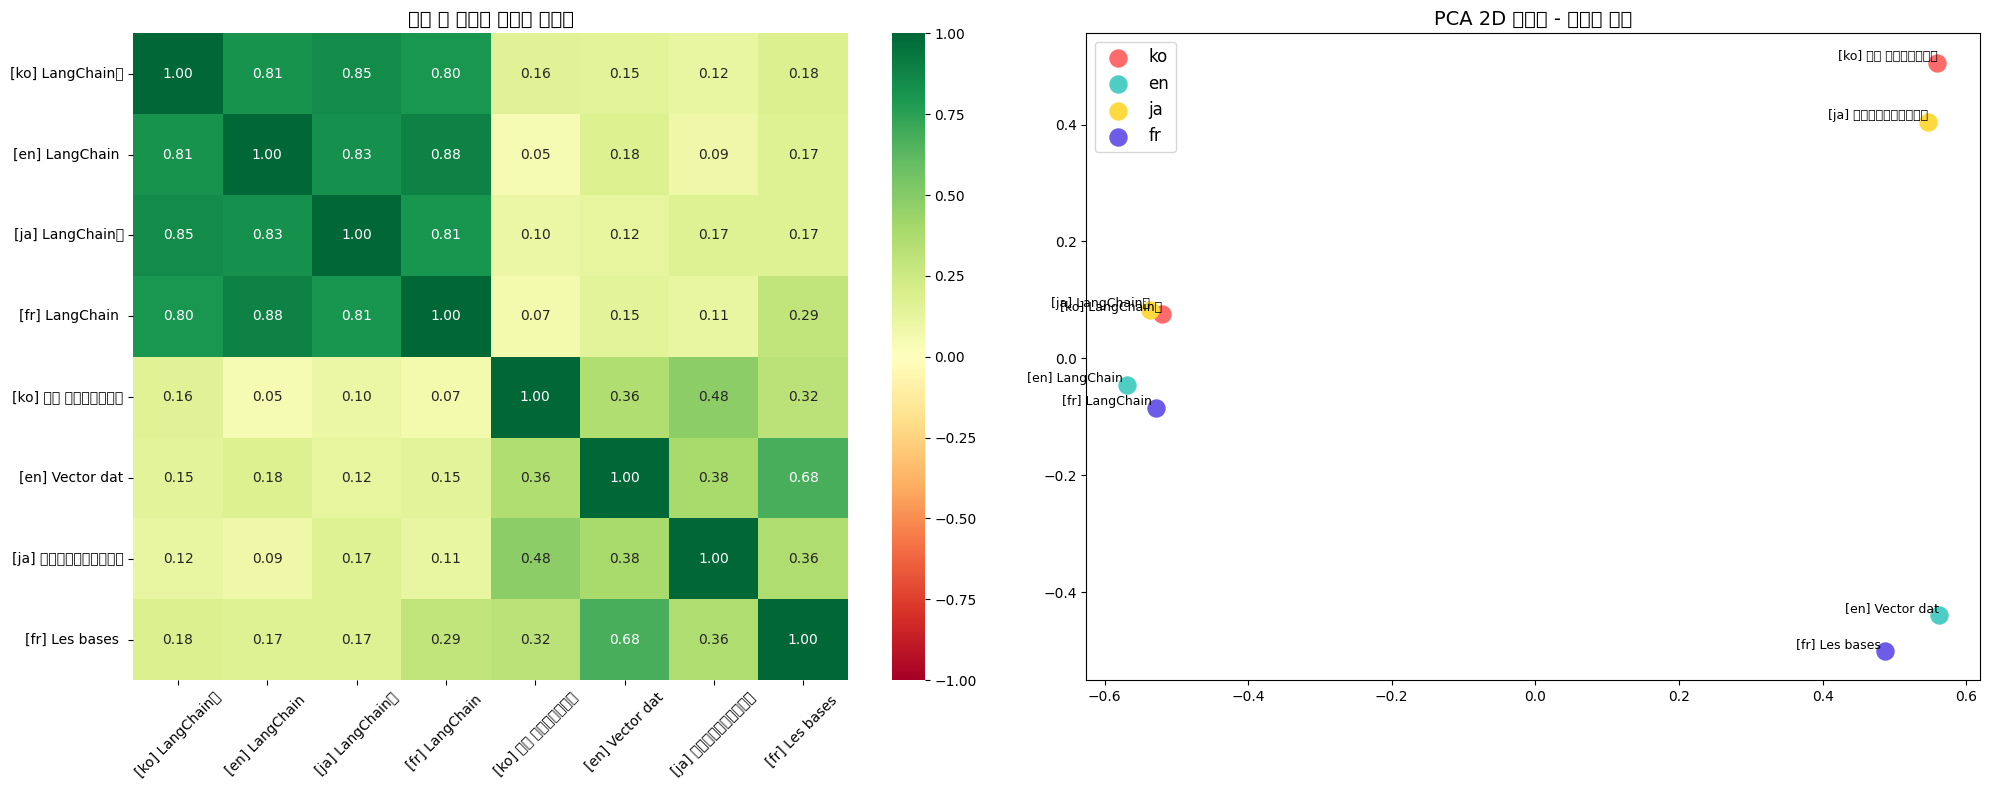

In [43]:
# +a 히트맵
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 히트맵 - 8x8 유사도 행렬
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 라벨 (언어 + 문장 앞 8글자)
labels = [f"[{doc.metadata['lang']}] {doc.page_content[:10]}" for doc in multilingual]

# 히트맵
sns.heatmap(
    sim_matrix,
    annot=True,        # 숫자 표시
    fmt=".2f",         # 소수점 2자리
    cmap="RdYlGn",     # 빨강(낮음) → 노랑 → 초록(높음)
    xticklabels=labels,
    yticklabels=labels,
    vmin=-1, vmax=1,
    ax=axes[0]
)
axes[0].set_title("문서 간 코사인 유사도 히트맵", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# 2. PCA 2차원 시각화
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(np.array(embs_multi))

lang_colors = {"ko": "#FF6B6B", "en": "#4ECDC4", "ja": "#FFD93D", "fr": "#6C5CE7"}

for i, doc in enumerate(multilingual):
    lang = doc.metadata["lang"]
    axes[1].scatter(coords_2d[i, 0], coords_2d[i, 1],
                    c=lang_colors[lang], s=150, label=lang)
    axes[1].annotate(
        f"[{lang}] {doc.page_content[:10]}",
        (coords_2d[i, 0], coords_2d[i, 1]),
        fontsize=9, ha='right', va='bottom'
    )

# 범례 중복 제거
handles, labels_legend = axes[1].get_legend_handles_labels()
unique = dict(zip(labels_legend, handles))
axes[1].legend(unique.values(), unique.keys(), fontsize=12)
axes[1].set_title("PCA 2D 시각화 - 언어별 분포", fontsize=14)

plt.tight_layout()
plt.show()

In [39]:
english_docs = [
    "LangChain is a framework for building LLM applications.",
    "RAG improves LLM accuracy by retrieving external documents.",
    "Vector databases store and search embedding vectors efficiently.",
    "Fine-tuning adapts a pre-trained model to specific data.",
    "Prompt engineering is the art of crafting effective instructions for AI.",
]

vs_en = FAISS.from_texts(english_docs, embeddings_model)

korean_queries = [
    "RAG가 뭐에요?", "벡터 데이터베이스 설명해주세요", "프롬프트 엔지니어링은?"
]

for q in korean_queries:
    results = vs_en.similarity_search_with_score(q, k=3)
    print(f"\nKR {q}")
    for doc, score in results:
        print(f" US {score}, {doc.page_content}")


KR RAG가 뭐에요?
 US 1.0918961763381958, RAG improves LLM accuracy by retrieving external documents.
 US 1.6631698608398438, LangChain is a framework for building LLM applications.
 US 1.8184484243392944, Prompt engineering is the art of crafting effective instructions for AI.

KR 벡터 데이터베이스 설명해주세요
 US 1.4557044506072998, Vector databases store and search embedding vectors efficiently.
 US 1.7258802652359009, RAG improves LLM accuracy by retrieving external documents.
 US 1.7813594341278076, Fine-tuning adapts a pre-trained model to specific data.

KR 프롬프트 엔지니어링은?
 US 1.541314959526062, Prompt engineering is the art of crafting effective instructions for AI.
 US 1.7588646411895752, Vector databases store and search embedding vectors efficiently.
 US 1.772362232208252, Fine-tuning adapts a pre-trained model to specific data.
